# macro-supply-signals — Quickstart

This notebook walks through every public entry-point in the library:

1. **Setup** — API key and imports
2. **Individual `get_*` functions** — one cell per signal family
3. **The §5 output schema** — provenance columns every DataFrame carries
4. **Signal catalog** — rich metadata per signal; `fetch_signal` and `SignalClient`
5. **Combined view** — `SignalClient.pull_many(align="month_end")` for a macro panel

> **Prerequisite:** a free FRED API key at https://fred.stlouisfed.org/docs/api/api_key.html
> Set it in a `.env` file at the project root: `FRED_API_KEY=your_key_here`

## 1. Setup

In [7]:
# Standard library and third-party
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

START = "2010-01-01"  # change to narrow / widen the date window

## 2. Inflation signals

### 2a. CPI — Consumer Price Index (headline)

In [8]:
from macro_supply_signals.signals.inflation import get_cpi

cpi = get_cpi(start=START)
print(f"{len(cpi)} rows  |  {cpi['date'].min().date()} → {cpi['date'].max().date()}")
cpi.tail(6)

/Users/asthagupta/projects/macro-supply-signals/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


194 rows  |  2010-01-01 → 2026-03-01


,date,native_series_id,value,cpi_yoy,cpi_mom,signal_id,frequency,source
188,2025-09-01,CPIAUCSL,324.2450,3.0226,0.2951,inflation.cpi_headline,M,fred
189,2025-11-01,CPIAUCSL,325.0630,2.9883,0.2523,inflation.cpi_headline,M,fred
190,2025-12-01,CPIAUCSL,326.0310,3.0023,0.2978,inflation.cpi_headline,M,fred
191,2026-01-01,CPIAUCSL,326.5880,2.8287,0.1708,inflation.cpi_headline,M,fred
192,2026-02-01,CPIAUCSL,327.4600,2.6646,0.2670,inflation.cpi_headline,M,fred
193,2026-03-01,CPIAUCSL,330.2930,3.3202,0.8651,inflation.cpi_headline,M,fred


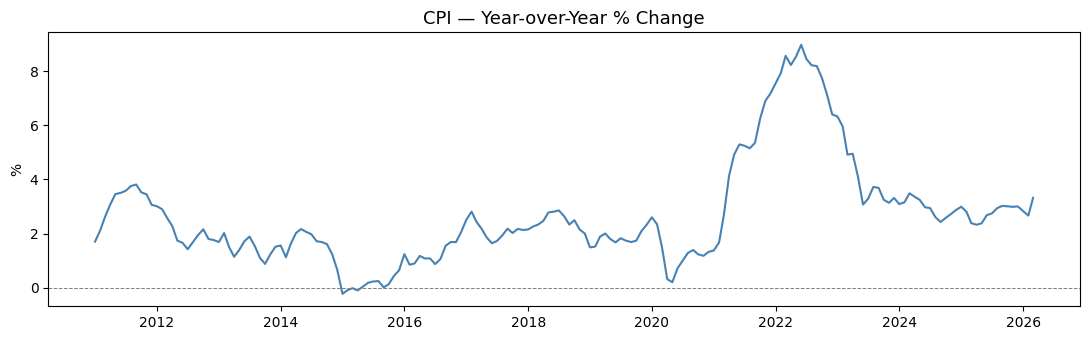

In [9]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(cpi["date"], cpi["cpi_yoy"], linewidth=1.5, color="steelblue")
ax.axhline(0, color="grey", linewidth=0.7, linestyle="--")
ax.set_title("CPI — Year-over-Year % Change", fontsize=13)
ax.set_ylabel("%")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

### 2b. PPI — Producer Price Index (all commodities)

In [10]:
from macro_supply_signals.signals.ppi import get_ppi

ppi = get_ppi(start=START)
ppi.tail(6)

,date,native_series_id,value,ppi_yoy,ppi_mom,signal_id,frequency,source
189,2025-10-01,PPIACO,260.5910,2.9674,-0.5583,inflation.ppi_all_commodities,M,fred
190,2025-11-01,PPIACO,261.9140,3.4371,0.5077,inflation.ppi_all_commodities,M,fred
191,2025-12-01,PPIACO,261.3490,3.1276,-0.2157,inflation.ppi_all_commodities,M,fred
192,2026-01-01,PPIACO,263.4850,2.3799,0.8173,inflation.ppi_all_commodities,M,fred
193,2026-02-01,PPIACO,269.2960,3.7758,2.2054,inflation.ppi_all_commodities,M,fred
194,2026-03-01,PPIACO,274.1020,6.0253,1.7847,inflation.ppi_all_commodities,M,fred


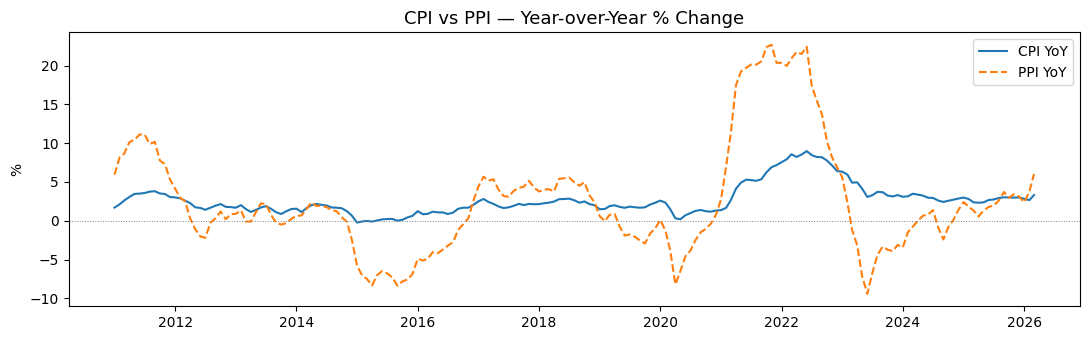

In [11]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(cpi["date"], cpi["cpi_yoy"], label="CPI YoY", linewidth=1.5)
ax.plot(ppi["date"], ppi["ppi_yoy"], label="PPI YoY", linewidth=1.5, linestyle="--")
ax.axhline(0, color="grey", linewidth=0.7, linestyle=":")
ax.set_title("CPI vs PPI — Year-over-Year % Change", fontsize=13)
ax.set_ylabel("%")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

## 3. Activity — Industrial Production

In [12]:
from macro_supply_signals.signals.industrial import get_industrial_production

ip = get_industrial_production(start=START)
ip.tail(6)

,date,native_series_id,value,ip_yoy,ip_mom,signal_id,frequency,source
189,2025-10-01,INDPRO,101.2195,1.7593,-0.4411,activity.industrial_production,M,fred
190,2025-11-01,INDPRO,101.0810,1.8012,-0.1368,activity.industrial_production,M,fred
191,2025-12-01,INDPRO,101.6113,1.2798,0.5246,activity.industrial_production,M,fred
192,2026-01-01,INDPRO,101.5954,1.5297,-0.0156,activity.industrial_production,M,fred
193,2026-02-01,INDPRO,102.3440,1.2312,0.7368,activity.industrial_production,M,fred
194,2026-03-01,INDPRO,101.7898,0.7417,-0.5415,activity.industrial_production,M,fred


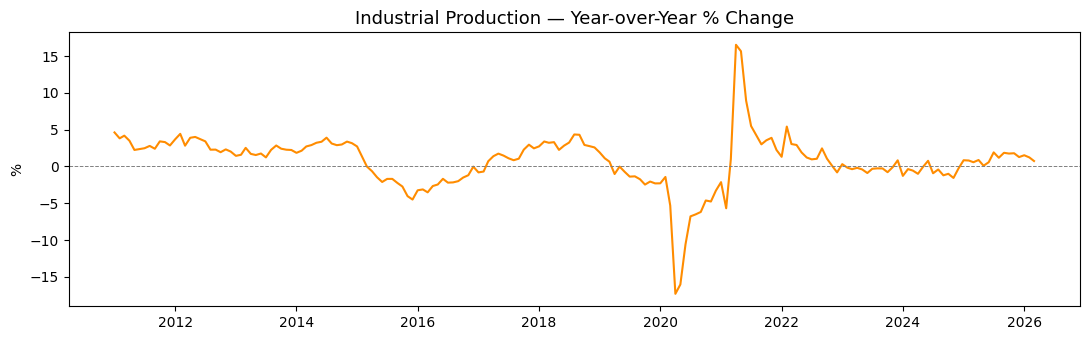

In [13]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(ip["date"], ip["ip_yoy"], linewidth=1.5, color="darkorange")
ax.axhline(0, color="grey", linewidth=0.7, linestyle="--")
ax.set_title("Industrial Production — Year-over-Year % Change", fontsize=13)
ax.set_ylabel("%")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

## 4. Energy — WTI and Brent crude

In [14]:
from macro_supply_signals.signals.energy import get_wti, get_brent

wti   = get_wti(start=START)
brent = get_brent(start=START)

print("WTI:")
print(wti.tail(4).to_string(index=False))
print("\nBrent:")
print(brent.tail(4).to_string(index=False))

WTI:
      date native_series_id   value  chg_1d  chg_30d        signal_id frequency source
2026-04-22       DCOILWTICO 94.7600  1.1961  13.2003 energy.crude_wti         D   fred
2026-04-23       DCOILWTICO 99.2700  4.7594  14.3664 energy.crude_wti         D   fred
2026-04-24       DCOILWTICO 98.4200 -0.8563   2.9390 energy.crude_wti         D   fred
2026-04-27       DCOILWTICO 99.8900  1.4936   1.4318 energy.crude_wti         D   fred

Brent:
      date native_series_id    value  chg_1d  chg_30d          signal_id frequency source
2026-04-22     DCOILBRENTEU 113.4400  6.8777  20.2332 energy.crude_brent         D   fred
2026-04-23     DCOILBRENTEU 113.2500 -0.1675  26.0574 energy.crude_brent         D   fred
2026-04-24     DCOILBRENTEU 111.8600 -1.2274  22.9501 energy.crude_brent         D   fred
2026-04-27     DCOILBRENTEU 113.8900  1.8148  11.2424 energy.crude_brent         D   fred


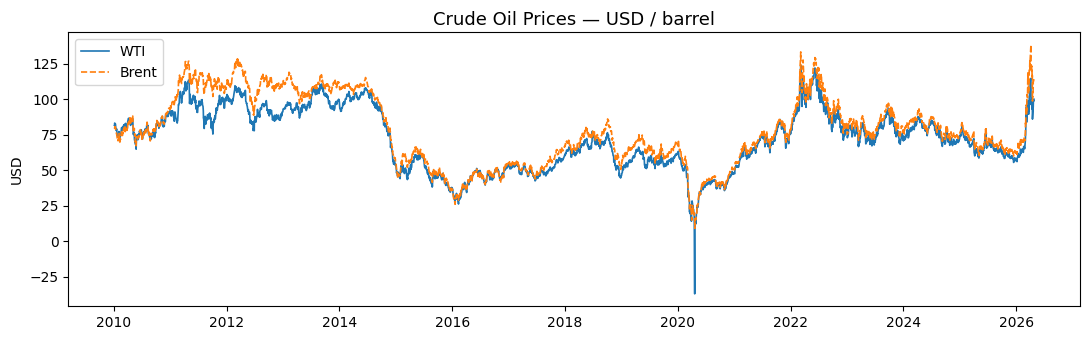

In [15]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(wti["date"],   wti["value"],   label="WTI",   linewidth=1.2)
ax.plot(brent["date"], brent["value"], label="Brent", linewidth=1.2, linestyle="--")
ax.set_title("Crude Oil Prices — USD / barrel", fontsize=13)
ax.set_ylabel("USD")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

## 5. FX — USD Broad Nominal Index

In [16]:
from macro_supply_signals.signals.fx import get_usd_index

usd = get_usd_index(start=START)
usd.tail(6)

,date,native_series_id,value,chg_1d,chg_30d,signal_id,frequency,source
4055,2026-04-17,DTWEXBGS,118.0795,-0.2383,-1.1813,fx.usd_broad_nominal,D,fred
4056,2026-04-20,DTWEXBGS,118.2374,0.1337,-1.0691,fx.usd_broad_nominal,D,fred
4057,2026-04-21,DTWEXBGS,118.4331,0.1655,-0.2463,fx.usd_broad_nominal,D,fred
4058,2026-04-22,DTWEXBGS,118.6004,0.1413,-0.5768,fx.usd_broad_nominal,D,fred
4059,2026-04-23,DTWEXBGS,118.7155,0.0970,-0.9240,fx.usd_broad_nominal,D,fred
4060,2026-04-24,DTWEXBGS,118.7294,0.0117,-1.5117,fx.usd_broad_nominal,D,fred


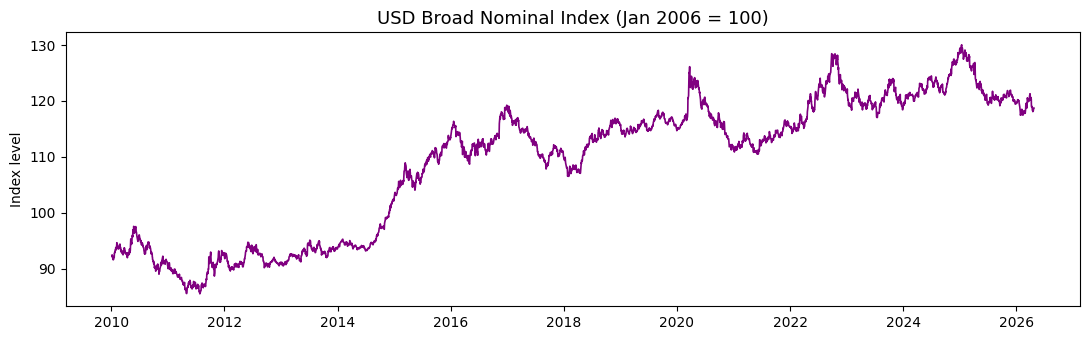

In [17]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(usd["date"], usd["value"], linewidth=1.2, color="purple")
ax.set_title("USD Broad Nominal Index (Jan 2006 = 100)", fontsize=13)
ax.set_ylabel("Index level")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

## 6. The §5 output schema

Every DataFrame returned by a `get_*` function (or `fetch_signal`) carries the same
provenance columns defined in §5 of the design doc:

| Column | Type | Description |
|--------|------|-------------|
| `date` | `datetime64[ns]` | Observation date |
| `signal_id` | `str` | Stable logical id, e.g. `inflation.cpi_headline` |
| `native_series_id` | `str` | Vendor series identifier, e.g. `CPIAUCSL` |
| `value` | `float` | Primary level for the signal |
| `frequency` | `str` | `D` (daily) or `M` (monthly) |
| `source` | `str` | Data provider — currently always `fred` |
| `retrieved_at` | `datetime64[ns, UTC]` | UTC timestamp of the fetch — useful for reproducibility |

Derived columns (`cpi_yoy`, `chg_1d`, etc.) are appended after the schema columns
and can be suppressed with `include_derived=False`.

In [ ]:
SCHEMA_COLS = ["date", "signal_id", "native_series_id", "value", "frequency", "source", "retrieved_at"]

for name, df in [("CPI", cpi), ("PPI", ppi), ("IP", ip), ("WTI", wti), ("Brent", brent), ("USD", usd)]:
    missing = [c for c in SCHEMA_COLS if c not in df.columns]
    status  = "✓" if not missing else f"✗ missing {missing}"
    print(f"{name:6s}  {status}  signal_id={df['signal_id'].iloc[0]!r}  freq={df['frequency'].iloc[0]!r}")

In [ ]:
# include_derived=False returns only the schema columns — useful when you want
# to apply your own transforms or keep frames small for joining.
slim_cpi = get_cpi(start="2023-01-01", include_derived=False)
print("Full columns:", list(cpi.columns))
print("Slim columns:", list(slim_cpi.columns))
slim_cpi.tail(3)

## 7. Signal catalog

Every signal carries human-readable metadata alongside its technical spec —
*why* it matters for supply-chain analytics, units, seasonal adjustment, and join hints.

In [ ]:
from macro_supply_signals.catalog import (
    fetch_signal,
    INFLATION_CPI_HEADLINE,
    INFLATION_PPI_ALL_COMMODITIES,
    ACTIVITY_INDUSTRIAL_PRODUCTION,
    ENERGY_CRUDE_WTI,
    ENERGY_CRUDE_BRENT,
    FX_USD_BROAD_NOMINAL,
    SIGNALS_BY_ID,
)

for sid, spec in SIGNALS_BY_ID.items():
    print(f"{spec.title}")
    print(f"  id:     {spec.signal_id}")
    print(f"  series: {spec.native_series_id}  |  freq={spec.frequency}  |  units={spec.units}")
    print(f"  adj:    {spec.seasonal_adjustment}")
    print(f"  tags:   {', '.join(spec.supply_chain_tags)}")
    print(f"  hint:   {spec.downstream_join_hint[:80]}...")
    print()

### 7b. `fetch_signal` — pull by stable id

All `get_*` functions are thin wrappers around `fetch_signal`. You can call it
directly using the stable id constants — useful for batch tooling.

In [ ]:
# fetch_signal returns the same DataFrame shape as the matching get_* function
df_via_catalog = fetch_signal(INFLATION_CPI_HEADLINE, start=START)
df_via_catalog.tail(4)

### 7c. `SignalClient` — batch pulls

`SignalClient` is the recommended entry point when pulling more than one signal.
It binds the API key once and exposes two methods:

| Method | Returns | When to use |
|--------|---------|-------------|
| `pull(signal_id)` | `DataFrame` | Same as `get_*`, key bound at construction |
| `pull_many(ids)` | `dict[str, DataFrame]` | Independent frames, no alignment |
| `pull_many(ids, align="month_end")` | wide `DataFrame` | Aligned panel for modelling / charting |

The aligned panel uses a two-level `MultiIndex` on columns: `(signal_id, column_name)`.
No interpolation is applied — gaps remain `NaN`.

In [ ]:
from macro_supply_signals import SignalClient

client = SignalClient()  # reads FRED_API_KEY from environment

# pull_many with no align returns a plain dict keyed by signal_id
frames = client.pull_many(
    [INFLATION_CPI_HEADLINE, INFLATION_PPI_ALL_COMMODITIES],
    start="2024-01-01",
)
print("Keys:", list(frames.keys()))
print(f"CPI rows: {len(frames[INFLATION_CPI_HEADLINE])}")
frames[INFLATION_CPI_HEADLINE].tail(3)

## 8. Combined macro snapshot

`client.pull_many(align="month_end")` pulls all six signals and resamples them to
calendar month-end in one call. Daily signals are downsampled to their last
observation of the month; no interpolation is applied.

In [ ]:
ALL_SIGNALS = [
    INFLATION_CPI_HEADLINE,
    INFLATION_PPI_ALL_COMMODITIES,
    ACTIVITY_INDUSTRIAL_PRODUCTION,
    ENERGY_CRUDE_WTI,
    ENERGY_CRUDE_BRENT,
    FX_USD_BROAD_NOMINAL,
]

panel = client.pull_many(ALL_SIGNALS, start=START, align="month_end")

print(f"{len(panel)} monthly rows")
print(f"Column levels: {panel.columns.names}")
panel.tail(6)

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Slice each signal's column from the MultiIndex panel
cpi_yoy   = panel[INFLATION_CPI_HEADLINE]["cpi_yoy"]
ppi_yoy   = panel[INFLATION_PPI_ALL_COMMODITIES]["ppi_yoy"]
ip_yoy    = panel[ACTIVITY_INDUSTRIAL_PRODUCTION]["ip_yoy"]
wti_val   = panel[ENERGY_CRUDE_WTI]["value"]
brent_val = panel[ENERGY_CRUDE_BRENT]["value"]
usd_val   = panel[FX_USD_BROAD_NOMINAL]["value"]

# Inflation
axes[0].plot(panel.index, cpi_yoy, label="CPI YoY %")
axes[0].plot(panel.index, ppi_yoy, label="PPI YoY %", linestyle="--")
axes[0].axhline(0, color="grey", linewidth=0.7, linestyle=":")
axes[0].set_title("Inflation (YoY %)", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].set_ylabel("%")

# Energy
axes[1].plot(panel.index, wti_val,   label="WTI")
axes[1].plot(panel.index, brent_val, label="Brent", linestyle="--")
axes[1].set_title("Crude Oil (USD / barrel)", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].set_ylabel("USD")

# USD + IP
ax2b = axes[2].twinx()
axes[2].plot(panel.index, usd_val, label="USD index", color="purple")
ax2b.plot(panel.index, ip_yoy,    label="IP YoY %",  color="darkorange", linestyle="--")
axes[2].set_title("USD Index vs Industrial Production YoY %", fontsize=11)
axes[2].set_ylabel("USD index", color="purple")
ax2b.set_ylabel("IP YoY %", color="darkorange")
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, fontsize=9)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Macro Supply-Chain Dashboard", fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()